In [1]:
from fastai.vision.all import *

In [2]:
predictor = load_learner('./models/predictor.pkl')
classifier = load_learner('./models/classifier.pkl')

/media/Delta/code/Master/Master-project/vibration_model/.venv/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [3]:
from make import load_data_for_pipeline, load_primary_data
from validation_util import split

spec, labels = load_data_for_pipeline()
pred_spec, pred_label = load_primary_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 

In [4]:
TARGET_HW  = (112,112)     # (H, W)

In [5]:
def get_x_pred(i):
    arr = pred_spec[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
        arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_x_classify(i):
    arr = spec[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
        arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_y_pred(i):
    return pred_label[i]

def get_y_classify(i):
    return labels[i]

In [6]:
predictor.predict(get_x_pred(3))[0] == 'Fall'

True

In [7]:
result_1 = []

for i in range(len(pred_spec)):
    if predictor.predict(get_x_pred(i))[0] == 'Fall':
        result_1.append('Fall')
    else:
        result_1.append("Not Fall")

<Axes: >

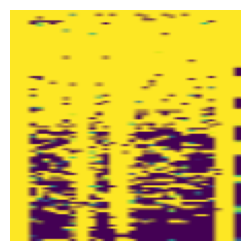

In [8]:
get_x_pred(0).show()

In [9]:
result = []

for i in range(len(spec)):
    if predictor.predict(get_x_classify(i))[0] == 'Fall':
        result.append(classifier.predict(get_x_classify(i))[0])
    else:
        result.append("Not Fall")

In [10]:
result

['Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Hard Fall',
 'Controlled Fall',
 'Hard Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fa

In [11]:
labels

['Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fal

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [13]:
accuracy_score(pred_label, result_1)

0.9966666666666667

In [14]:
accuracy_score(labels, result)

0.9825

In [15]:
pred_block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x_pred,
    get_y=get_y_pred,
)

block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x_classify,
    get_y=get_y_classify,
)

pred_items = list(range(len(pred_spec)))
items = list(range(len(spec)))

pred_dls = pred_block.dataloaders(pred_items, bs=16)
dls = block.dataloaders(items, bs=16)

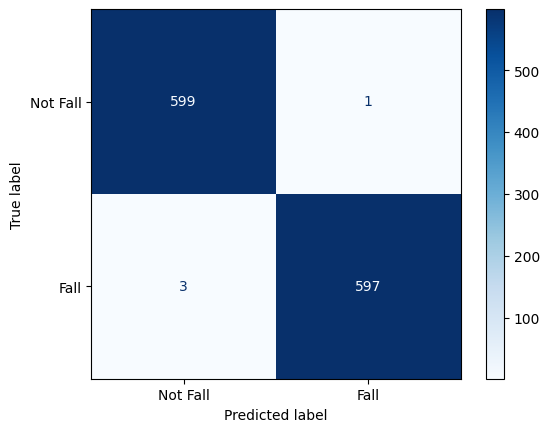

In [18]:
cm = confusion_matrix(pred_label, result_1, labels=pred_dls.vocab)
disp = ConfusionMatrixDisplay(cm, display_labels=pred_dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()

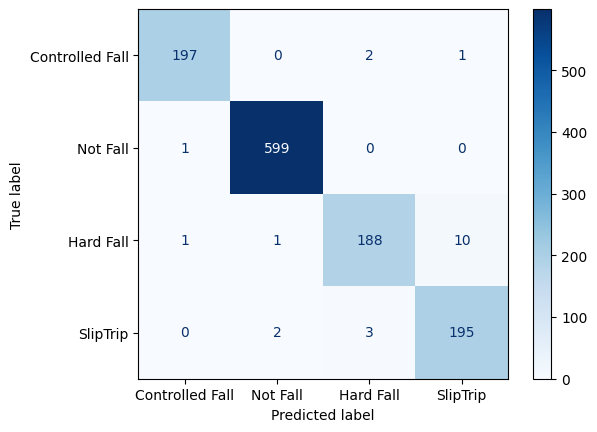

In [19]:
cm = confusion_matrix(labels, result, labels=dls.vocab)
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()